<a href="https://colab.research.google.com/github/itsJolvii/MSCS-335/blob/main/lung_cancer_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
# import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
# upload dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

Saving lung_data_4.csv to lung_data_4 (3).csv


In [108]:
# Data Cleaning & Preprocessing
# Standardize text
df = df.apply(lambda x: x.str.upper() if x.dtype == "object" else x) # ensures all text become uppercase

# Converting binary (YES/NO) to 1/0
# Automatically detect other binary columns
binary_cols = []

for col in df.columns:
        unique_vals = set(df[col].dropna().unique()) # looks for unique values

        if unique_vals.issubset({1, 2}): # if unique values include YES/NO only, then add it to list of binary columns
            binary_cols.append(col)

print("Binary columns detected:", binary_cols)

# convert binary columns to 0/1
for col in binary_cols:
    df[col] = df[col].map({1: 0, 2: 1})

# Note: If no multi-class categories then no One-Hot encoding, only binary encoding.
# Also, becareful if there are columns with only 2 unique values but are actually categorical and non-binary, like Gender

# manual conversions
df["GENDER"] = df["GENDER"].map({"M": 1, "F": 0})
df["LUNG_CANCER"] = df["LUNG_CANCER"].map({"YES": 1, "NO": 0})

# define target & features (split X,y)

X=df.drop("LUNG_CANCER", axis=1)
y=df["LUNG_CANCER"]

Binary columns detected: ['SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']


In [109]:
df["LUNG_CANCER"].value_counts(dropna=False)

,count
LUNG_CANCER,
1,270
0,39


In [110]:
# train/test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # ensures the train and test sets have same proportion of cancer/non-cancer
)

In [111]:
# Scale features
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [112]:
# Check outputs
print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)
print("Target distribution:\n", y.value_counts())

Shape of training data: (247, 15)
Shape of test data: (62, 15)
Target distribution:
 LUNG_CANCER
1    270
0     39
Name: count, dtype: int64


In [113]:
# ------ LOGISTIC REGRESSION---------
# create model
log_model = LogisticRegression(
    solver='lbfgs', # solver finds best weights. using advanced gradient descent optimizer here
    max_iter=1000, #ensures convergence
    class_weight='balanced' # helps with medical data imbalance. punishes mistakes on minority class.
)

log_model.fit(x_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [114]:
# make predictions
y_pred = log_model.predict(x_test_scaled)

# get probabilities (for AUC)
y_prob = log_model.predict_proba(x_test_scaled)[:, 1]


In [115]:
# Evaluation metrics
precision_logreg = precision_score(y_test, y_pred)
recall_logreg = recall_score(y_test, y_pred)
f1_logreg = f1_score(y_test, y_pred)
auc_logreg = roc_auc_score(y_test, y_prob)

print("Precision:", precision_logreg)
print("Recall:", recall_logreg)
print("F1 Score:", f1_logreg)
print("AUC-ROC:", auc_logreg)

Precision: 1.0
Recall: 0.8518518518518519
F1 Score: 0.92
AUC-ROC: 0.9537037037037037


In [116]:
# ------- SVM -------------
# create model
svm_model = SVC(
    kernel='rbf', # radial basis function - flexible, curved decision boundaries
    probability=True, # we want probability outputs for computing AUC
    class_weight='balanced' # handles imbalance. otherwise model can cheat by predicting majority class.
)

# train (fit)
svm_model.fit(x_train_scaled, y_train)

# predict
y_pred_svm = svm_model.predict(x_test_scaled)

# get probabilities
y_prob_svm = svm_model.predict_proba(x_test_scaled)[:, 1]

In [117]:
# Evaluate SVM
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)
print("SVM AUC:", auc_svm)

Precision: 0.9791666666666666
Recall: 0.8703703703703703
F1 Score: 0.9215686274509803
SVM AUC: 0.9583333333333333


In [118]:
# ------- RANDOM FOREST ----------------
# create lots of decision trees and then let them vote

rf_model = RandomForestClassifier(
    n_estimators=200, # 200 trees. more trees = more stable
    random_state=42,
    class_weight='balanced'
)

# train
rf_model.fit(x_train, y_train)

# predict
y_pred_rf = rf_model.predict(x_test)

# predict probabilities for AUC
y_prob_rf = rf_model.predict_proba(x_test)[:, 1]

In [119]:
# Evaluate Random Forest
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("RF Precision:", precision_rf)
print("RF Recall:", recall_rf)
print("RF F1:", f1_rf)
print("RF AUC:", auc_rf)

RF Precision: 0.9444444444444444
RF Recall: 0.9444444444444444
RF F1: 0.9444444444444444
RF AUC: 0.9490740740740741


In [120]:
# Model Comparisons
# comparison table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Precision": [precision, precision_svm, precision_rf],
    "Recall": [recall, recall_svm, recall_rf],
    "F1 Score": [f1, f1_svm, f1_rf],
    "AUC-ROC": [auc, auc_svm, auc_rf]
})

results_sorted = results.sort_values(by="AUC-ROC", ascending=False) # sort by best model, using AUC-ROC as main metric
results_sorted

,Model,Precision,Recall,F1 Score,AUC-ROC
1,SVM,0.979167,0.870370,0.921569,0.958333
2,Random Forest,0.944444,0.944444,0.944444,0.949074
0,Logistic Regression,0.539936,0.555921,0.547812,0.534706


<Figure size 1000x600 with 0 Axes>

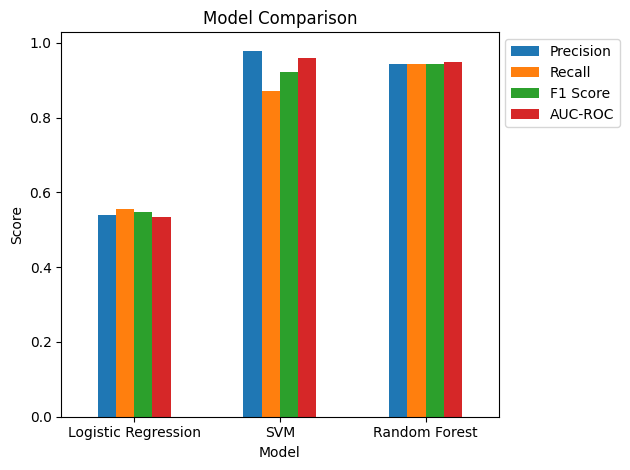

In [121]:
# bar chart
plt.figure(figsize=(10,6))   # make plot wider

results.set_index("Model").plot(kind="bar")

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="upper left", bbox_to_anchor=(1,1))  # move legend outside
plt.tight_layout()   # prevent clipping
plt.show()

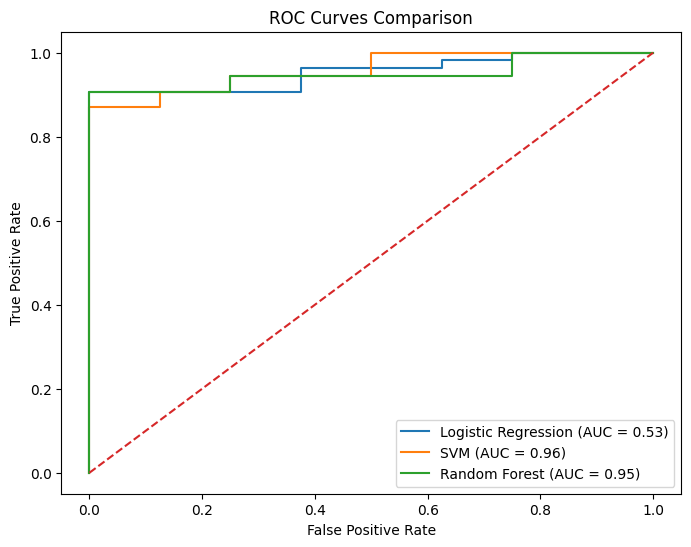

In [122]:
# ROC curves
# X-axis = False Positive Rate, Y-axis = True Positive Rate (Recall)
# perfect model hugs top left corner
# AUC (Area Under Curve): 0.5 = guess, 0.7-0.8 = decent, 0.8-0.9 = good, 0.9+ = excellent

# compute curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)

# plot curves
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC = {auc_rf:.2f})")

# Diagonal = random guessing baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

In [123]:
y.value_counts()

,count
LUNG_CANCER,
1,270
0,39


In [124]:
# testing dataset
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
dummy.score(x_test, y_test)

0.8709677419354839